## 9. Leakage And Forecast-Origin Availability Assumptions

The curated schema does not contain publication dates. The metadata file below is an explicit assumption set for a one-quarter-ahead modelling workflow. It distinguishes the observation quarter, the release/publication lag, and the forecast origin, but it does not contain true historical release vintages. The project currently uses revised historical ABS/RBA/market data, so the safe-lag check is a transparent leakage-control assumption rather than a real-time data audit.

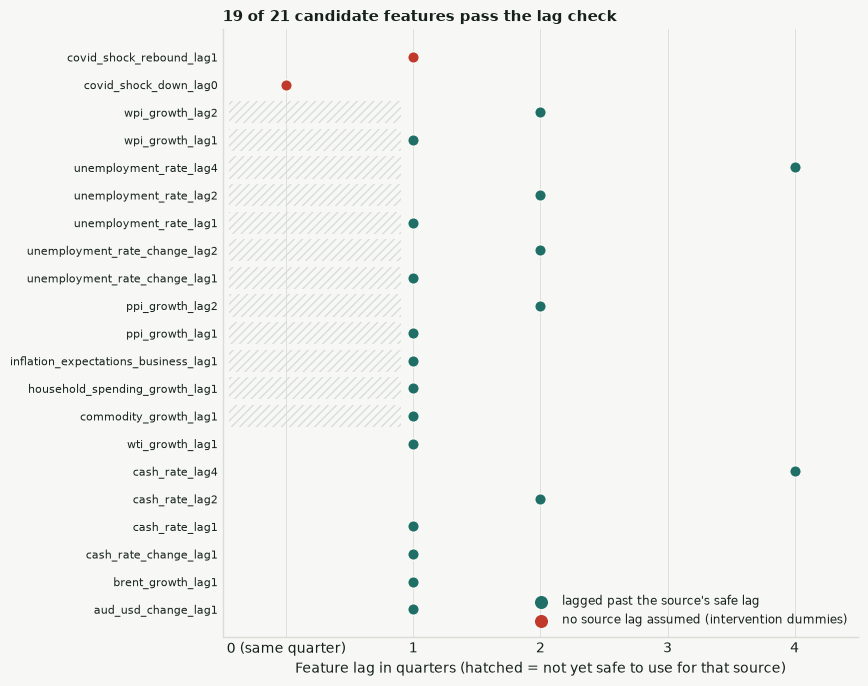

In [11]:
feature_availability = []
for feature in EXTERNAL_LAGGED_FEATURES:
    base = lag_base_name(feature)
    lag = feature_lag(feature)
    assumption = availability_assumptions.loc[availability_assumptions['variable'] == base]
    min_safe_lag = int(assumption['assumed_min_safe_lag_quarters'].iloc[0]) if not assumption.empty else np.nan
    feature_availability.append({
        'candidate_feature': feature,
        'variable': base,
        'feature_lag_quarters': lag,
        'assumed_min_safe_lag_quarters': min_safe_lag,
        'forecast_origin_safe_under_assumption': bool(pd.notna(min_safe_lag) and lag >= min_safe_lag),
    })

feature_availability = pd.DataFrame(feature_availability)
with plt.rc_context(BOOK_STYLE):
    f = feature_availability.sort_values(["assumed_min_safe_lag_quarters", "candidate_feature"]).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8.2, 0.29 * len(f) + 1.8))
    for y, r in f.iterrows():
        boundary = r["assumed_min_safe_lag_quarters"]
        if boundary > 0:
            ax.add_patch(plt.Rectangle((-0.45, y - 0.4), boundary - 0.05 + 0.4, 0.8, fill=False, hatch="////",
                                       edgecolor=GRID, linewidth=0))
        safe = bool(r["forecast_origin_safe_under_assumption"])
        ax.scatter(r["feature_lag_quarters"], y, s=70, color=ACCENT if safe else ALERT, edgecolor=PAPER, linewidth=1.1, zorder=3)
    ax.set_yticks(f.index, f["candidate_feature"], fontsize=8.2)
    ax.set_xticks([0, 1, 2, 3, 4], ["0 (same quarter)", "1", "2", "3", "4"])
    ax.set_xlim(-0.5, 4.5)
    ax.set_xlabel("Feature lag in quarters (hatched = not yet safe to use for that source)")
    n_safe = int(f["forecast_origin_safe_under_assumption"].sum())
    ax.scatter([], [], s=70, color=ACCENT, label="lagged past the source's safe lag")
    ax.scatter([], [], s=70, color=ALERT, label="no source lag assumed (intervention dummies)")
    ax.legend(frameon=False, fontsize=8.3, loc="lower right")
    ax.set_title(f"{n_safe} of {len(f)} candidate features pass the lag check", loc="left", fontsize=11, fontweight="bold")
    ax.grid(axis="y", visible=False)
    plt.show()

**Interpretation.** The assumed safe lag isn't uniform across sources, and that
difference is the actual mechanism behind "leakage-aware lags," not just a label. Market-observed
series (`cash_rate`, `wti_price`) get a 0-quarter minimum safe lag, since a policy rate or a
traded oil price is public the moment it's set. Administrative/survey series collected and
revised by statistical agencies (`unemployment_rate`, `wage_price_index`,
`producer_price_index`) all get a full quarter's buffer, since those can be revised after
first release and a naive same-quarter lag would risk leaking a later-revised number into a
forecast that couldn't have seen it. This chart is what `src/features.py`'s lag construction
actually encodes, not a fact verified against real ABS/RBA release calendars (the notebook
is explicit that this is an assumption set, not a real-time vintage audit).